# CS506 Midterm — Amazon Review Rating Prediction
Ridge Regression + user/product bias features + TF-IDF

In [36]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.data import load_train_data, load_test_data
from src.features import prepare_training_data, prepare_test_data
from src.model import train_ridge, evaluate_model, save_model, create_submission

## 1. Load data
The test IDs are embedded in train.csv with NaN scores — we extract them here.

In [37]:
raw = load_train_data('../data/train.csv')
test_ids_df = load_test_data('../data/test.csv')

# Split labeled vs unlabeled
labeled   = raw.dropna(subset=['Score']).copy()
test_df   = raw[raw['Id'].isin(test_ids_df['Id'])].copy()

print('Labeled rows :', len(labeled))
print('Test rows    :', len(test_df))
print('Score distribution:')
print(labeled['Score'].value_counts().sort_index())

Labeled rows : 125777
Test rows    : 13976
Score distribution:
Score
1.0     7593
2.0     7567
3.0    14857
4.0    28572
5.0    67188
Name: count, dtype: int64


## 2. Feature engineering
- User & product bias (mean rating per user/product)
- Numeric: helpfulness ratio, text length, exclamation/question marks, year/month
- TF-IDF on Summary + Text (30k features, 1-2 grams)

In [38]:
X, y, tfidf, svd, numeric_columns, labeled_df = prepare_training_data(
    raw,
    text_column='Text',
    max_features=30000,
    ngram_range=(1, 2)
)
print('Feature matrix shape:', X.shape)

TF-IDF matrix shape: (125777, 30000)


ValueError: not enough values to unpack (expected 6, got 5)

## 3. Train / validation split

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)

X_train: (100621, 30220)
X_valid: (25156, 30220)


## 4. Model: Ridge Regression
Ridge works well with high-dimensional sparse TF-IDF features. Alpha tuned by validation RMSE.

In [ ]:
best_rmse = 999
best_alpha = None
results = []

for alpha in [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]:
    model = train_ridge(X_train, y_train, alpha=alpha)
    rmse = evaluate_model(model, X_train, X_valid, y_train, y_valid, title=f'Ridge alpha={alpha}')
    results.append((alpha, rmse))
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

print(f'\nBest alpha: {best_alpha}  |  Best valid RMSE: {best_rmse:.4f}')


Ridge alpha=0.1
  Train RMSE : 0.5841
  Valid RMSE : 0.5870



Ridge alpha=1.0
  Train RMSE : 0.5768
  Valid RMSE : 0.5791



Ridge alpha=5.0
  Train RMSE : 0.5841
  Valid RMSE : 0.5870



Ridge alpha=10.0
  Train RMSE : 0.5842
  Valid RMSE : 0.5872



Ridge alpha=50.0
  Train RMSE : 0.5851
  Valid RMSE : 0.5881



Ridge alpha=100.0
  Train RMSE : 0.5864
  Valid RMSE : 0.5896

Best alpha: 1.0  |  Best valid RMSE: 0.5791


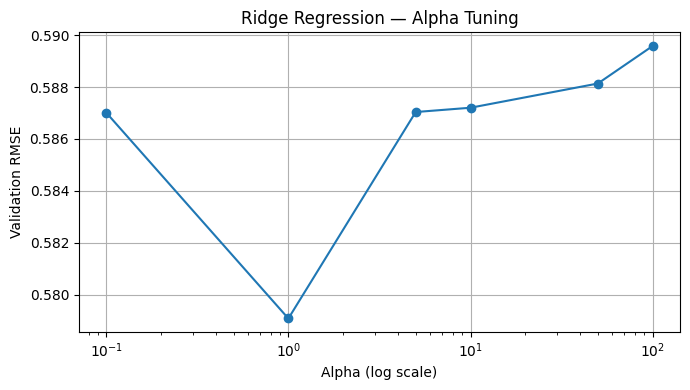

In [ ]:
alphas, rmses = zip(*results)
plt.figure(figsize=(7, 4))
plt.semilogx(alphas, rmses, marker='o')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Validation RMSE')
plt.title('Ridge Regression — Alpha Tuning')
plt.grid(True)
plt.tight_layout()
plt.savefig('../assets/ridge_alpha_tuning.png', dpi=100)
plt.show()

## 5. Train final model on all labeled data

In [ ]:
final_model = train_ridge(X, y, alpha=best_alpha)
save_model(final_model, '../ridge_regression_model.obj')
print('Final model trained and saved.')

Final model trained and saved.


## 6. Prepare test features and generate submission

In [ ]:
X_test = prepare_test_data(test_df, tfidf, svd, numeric_columns, labeled_df)
print('Test feature matrix shape:', X_test.shape)

submission = create_submission(
    final_model,
    test_df,
    X_test,
    output_path='../submissions/submission.csv',
    clip_range=(1, 5),
    round_predictions=False
)
print(submission.describe())
submission.head(10)

Test feature matrix shape: (13976, 30220)
Submission saved to ../submissions/submission.csv (13976 rows)
                 Id         Score
count  1.397600e+04  13976.000000
mean   8.473832e+05      4.080516
std    4.887796e+05      0.733606
min    6.300000e+01      1.000000
25%    4.237660e+05      3.709227
50%    8.522600e+05      4.228108
75%    1.269030e+06      4.611348
max    1.697410e+06      5.000000


,Id,Score
125777,1224650,4.395004
125778,1019381,3.502162
125779,504719,4.789800
125780,1622425,4.229705
125781,482286,4.792031
125782,1074829,4.430175
125783,1599357,3.976784
125784,1087427,4.960333
125785,203315,2.728135
125786,235783,4.951048


## 7. Score distribution check

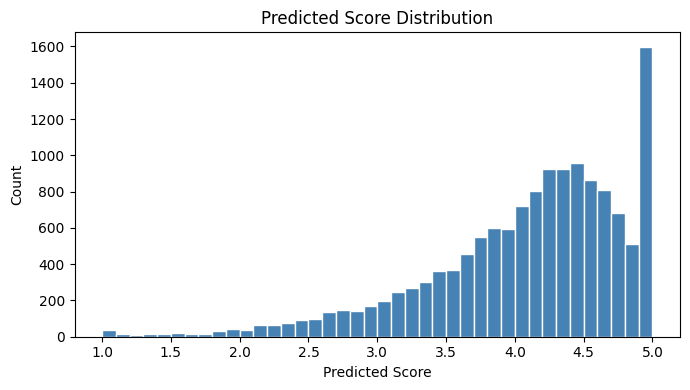

Validation RMSE (best): 0.5791


In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(submission['Score'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Predicted Score')
plt.ylabel('Count')
plt.title('Predicted Score Distribution')
plt.tight_layout()
plt.savefig('../assets/predicted_score_dist.png', dpi=100)
plt.show()
print('Validation RMSE (best):', round(best_rmse, 4))